In [12]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Resolve the 4D-avr/lorenz directory regardless of current working directory.
cwd = Path.cwd()
LORENZ_DIR = cwd

# Keep backward-compatible name used by older cells.
PATH = LORENZ_DIR

# Default to the standard results folder; fallback to latest results* folder if needed.
RESULTS_DIR = LORENZ_DIR / "outputs" / "results_seed_42_submit_v2_copy"

print(f"Using results directory: {RESULTS_DIR}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using results directory: /Odyssey/private/c23bouna/UE_G/score-da-demo/4D-avr/lorenz/outputs/results_seed_42_submit_v2_copy


## Settings

In [13]:
colors = plt.cm.viridis(np.linspace(0.2, 0.8, 5))

rc = {
    'axes.axisbelow': True,
    'axes.linewidth': 1.0,
    'axes.prop_cycle': plt.cycler('color', colors),
    'figure.dpi': 150,
    'figure.figsize': (6.4, 4.8),
    'font.size': 12.0,
    'legend.fontsize': 'xx-small',
    'lines.linewidth': 1.0,
    'lines.markersize': 2.5,
    'savefig.transparent': True,
    'xtick.labelsize': 'x-small',
    'xtick.major.width': 1.0,
    'ytick.labelsize': 'x-small',
    'ytick.major.width': 1.0,
    'font.family': ['serif'],
    'text.usetex': True,
}

plt.rcParams.update(rc)

## Statistics

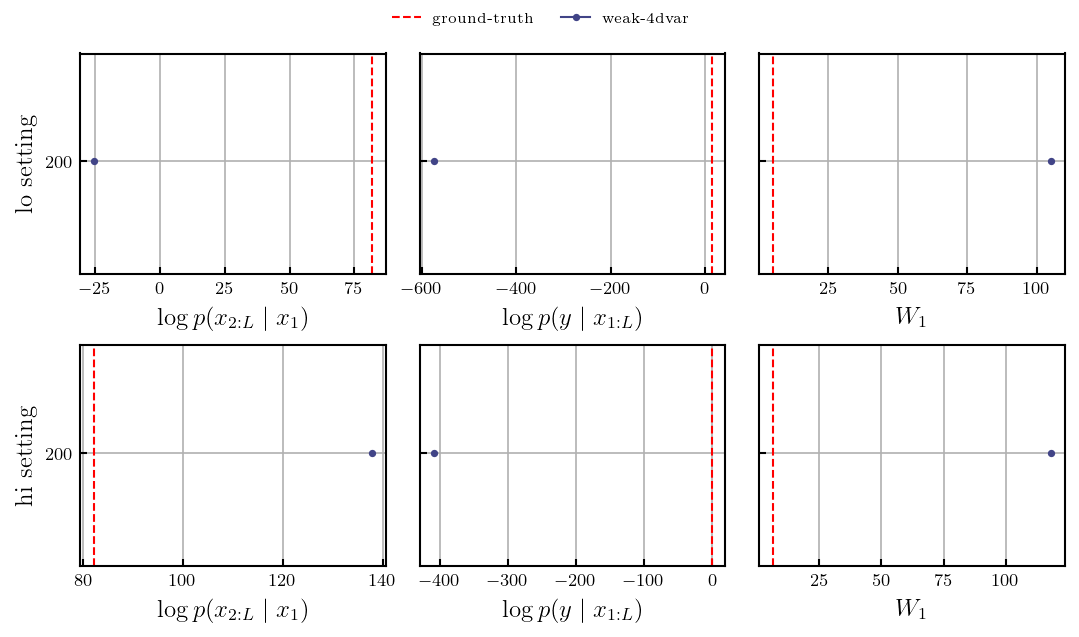

In [14]:
fig, axs = plt.subplots(2, 3, figsize=(7.2, 4.2), sharey='row')

metrics = [
    ("log_px", "$\\log p(x_{2:L} \\mid x_1)$"),
    ("log_py", "$\\log p(y \\mid x_{1:L})$"),
    ("w1", "$W_1$"),
]

for row, freq in enumerate(("lo", "hi")):
    csv_path = RESULTS_DIR / f"stats_{freq}.csv"
    
    # 4DVar format: i, method, setting, log_px, log_py, w1
    df = pd.read_csv(
        csv_path,
        header=None,
        names=["i", "method", "setting", "log_px", "log_py", "w1"],
    )
    df["setting"] = pd.to_numeric(df["setting"], errors="coerce")

    gt = df[df["method"] == "ground-truth"]
    w4d = df[df["method"] == "weak-4dvar"].copy()

    for col_idx, (column, xlabel) in enumerate(metrics):
        ax = axs[row, col_idx]

        # Ground-truth reference as median vertical line across observations.
        gt_vals = gt[column].replace([np.inf, -np.inf], np.nan).dropna()
        if not gt_vals.empty:
            ax.axvline(gt_vals.median(), ls="--", color="red", label="ground-truth")

        # Weak-4DVar can have multiple settings (e.g., different maxiter values).
        w_vals = w4d[["setting", column]].replace([np.inf, -np.inf], np.nan).dropna()
        if not w_vals.empty:
            agg = (
                w_vals.groupby("setting", dropna=False)[column]
                .median()
                .reset_index()
                .sort_values("setting")
            )
            ax.plot(agg[column], agg["setting"], "-o", label="weak-4dvar")

            y_ticks = sorted(int(v) for v in agg["setting"].unique())
            ax.set_yscale("symlog", base=2, linthresh=1, linscale=0.5)
            ax.set_yticks(y_ticks)
            ax.yaxis.set_major_formatter(mpl.ticker.ScalarFormatter())

        ax.set_xlabel(xlabel)
        if col_idx == 0:
            ax.set_ylabel(f"{freq} setting")
        ax.tick_params(direction="in")
        ax.grid()

# One shared legend from the first subplot that has handles.
handles, labels = [], []
for ax in axs.flat:
    h, l = ax.get_legend_handles_labels()
    if h:
        handles, labels = h, l
        break
if handles:
    fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)

fig.tight_layout(rect=[0, 0, 1, 0.95], pad=0.6)
fig.savefig("statistics_4dvar.pdf", pad_inches=0.025, bbox_inches="tight")

## Extra 4DVar Visualizations
Use these cells to inspect distributions, per-sample deviations, and NaN behavior in `stats_lo.csv` and `stats_hi.csv`.

In [15]:
# Load and align lo/hi results by sample index i
def load_stats(freq: str) -> pd.DataFrame:
    csv_path = RESULTS_DIR / f"stats_{freq}.csv"
    df = pd.read_csv(
        csv_path,
        header=None,
        names=["i", "method", "setting", "log_px", "log_py", "w1"],
    )
    df["freq"] = freq
    df["setting"] = pd.to_numeric(df["setting"], errors="coerce")
    return df

df_all = pd.concat([load_stats("lo"), load_stats("hi")], ignore_index=True)

# Split GT and weak-4dvar then align by sample index for direct comparison
gt = df_all[df_all["method"] == "ground-truth"].copy()
w4d = df_all[df_all["method"] == "weak-4dvar"].copy()

pair = gt.merge(
    w4d,
    on=["freq", "i"],
    how="inner",
    suffixes=("_gt", "_w4d"),
)

for metric in ["log_px", "log_py", "w1"]:
    pair[f"delta_{metric}"] = pair[f"{metric}_w4d"] - pair[f"{metric}_gt"]

display(df_all.head())
display(pair.head())

,i,method,setting,log_px,log_py,w1,freq
0,0,ground-truth,NaN,82.572243,14.428512,5.542079,lo
1,0,weak-4dvar,200.0,-70.016762,-822.426004,97.418045,lo
2,1,ground-truth,NaN,80.819336,13.354394,5.727213,lo
3,1,weak-4dvar,200.0,-10.671253,-566.214142,92.669495,lo
4,2,ground-truth,NaN,81.885925,14.912155,6.407186,lo


,i,method_gt,setting_gt,log_px_gt,log_py_gt,w1_gt,freq,method_w4d,setting_w4d,log_px_w4d,log_py_w4d,w1_w4d,delta_log_px,delta_log_py,delta_w1
0,0,ground-truth,NaN,82.572243,14.428512,5.542079,lo,weak-4dvar,200.0,-70.016762,-822.426004,97.418045,-152.589005,-836.854515,91.875966
1,1,ground-truth,NaN,80.819336,13.354394,5.727213,lo,weak-4dvar,200.0,-10.671253,-566.214142,92.669495,-91.490589,-579.568536,86.942282
2,2,ground-truth,NaN,81.885925,14.912155,6.407186,lo,weak-4dvar,200.0,-5.390859,-554.245596,86.722130,-87.276784,-569.157751,80.314944
3,3,ground-truth,NaN,83.492783,16.073395,5.009448,lo,weak-4dvar,200.0,35.185604,-354.192791,92.785271,-48.307178,-370.266186,87.775823
4,4,ground-truth,NaN,82.351944,12.628145,4.987960,lo,weak-4dvar,200.0,33.478580,-427.237631,109.855110,-48.873363,-439.865777,104.867150


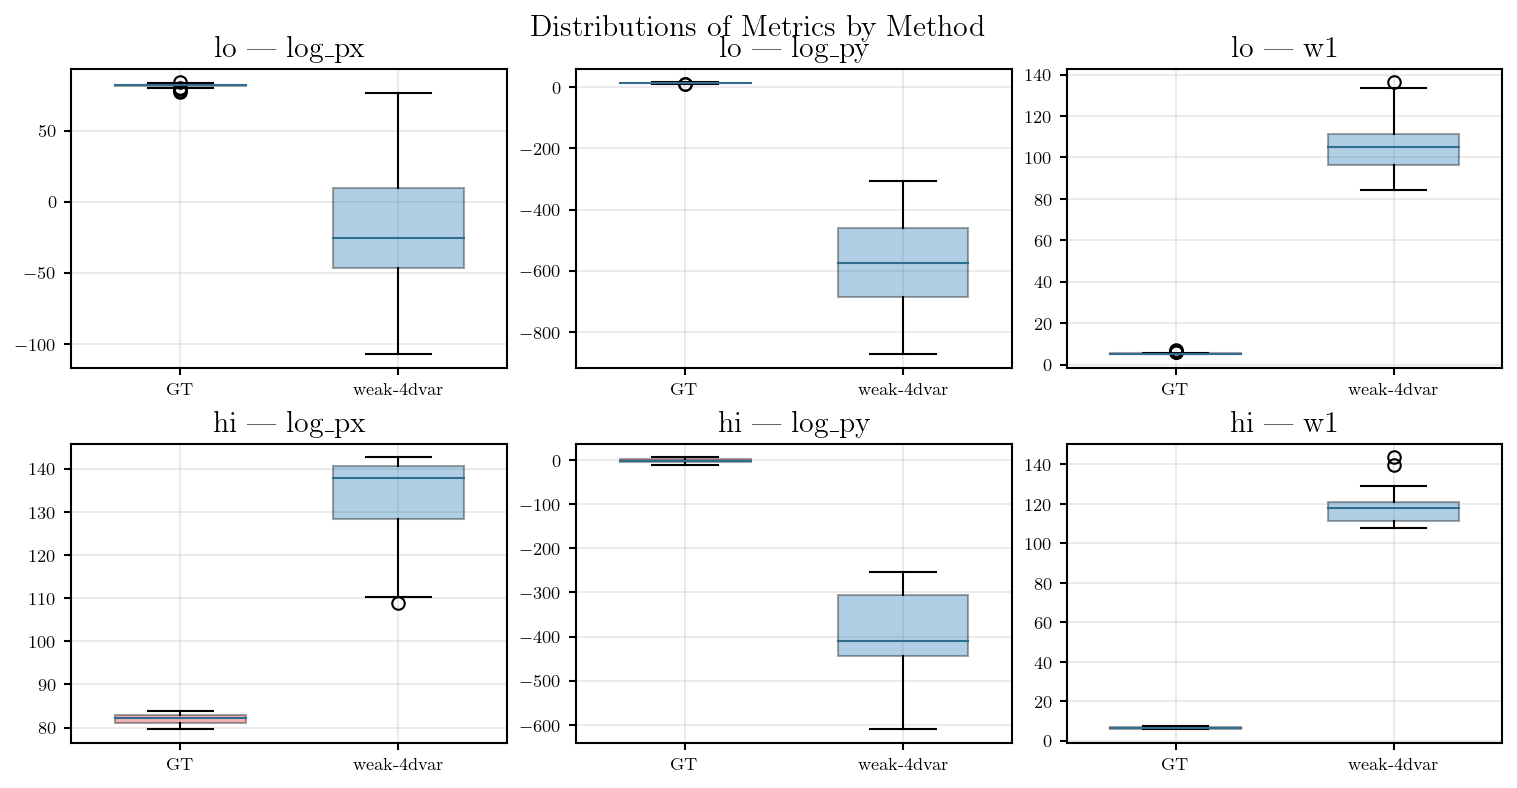

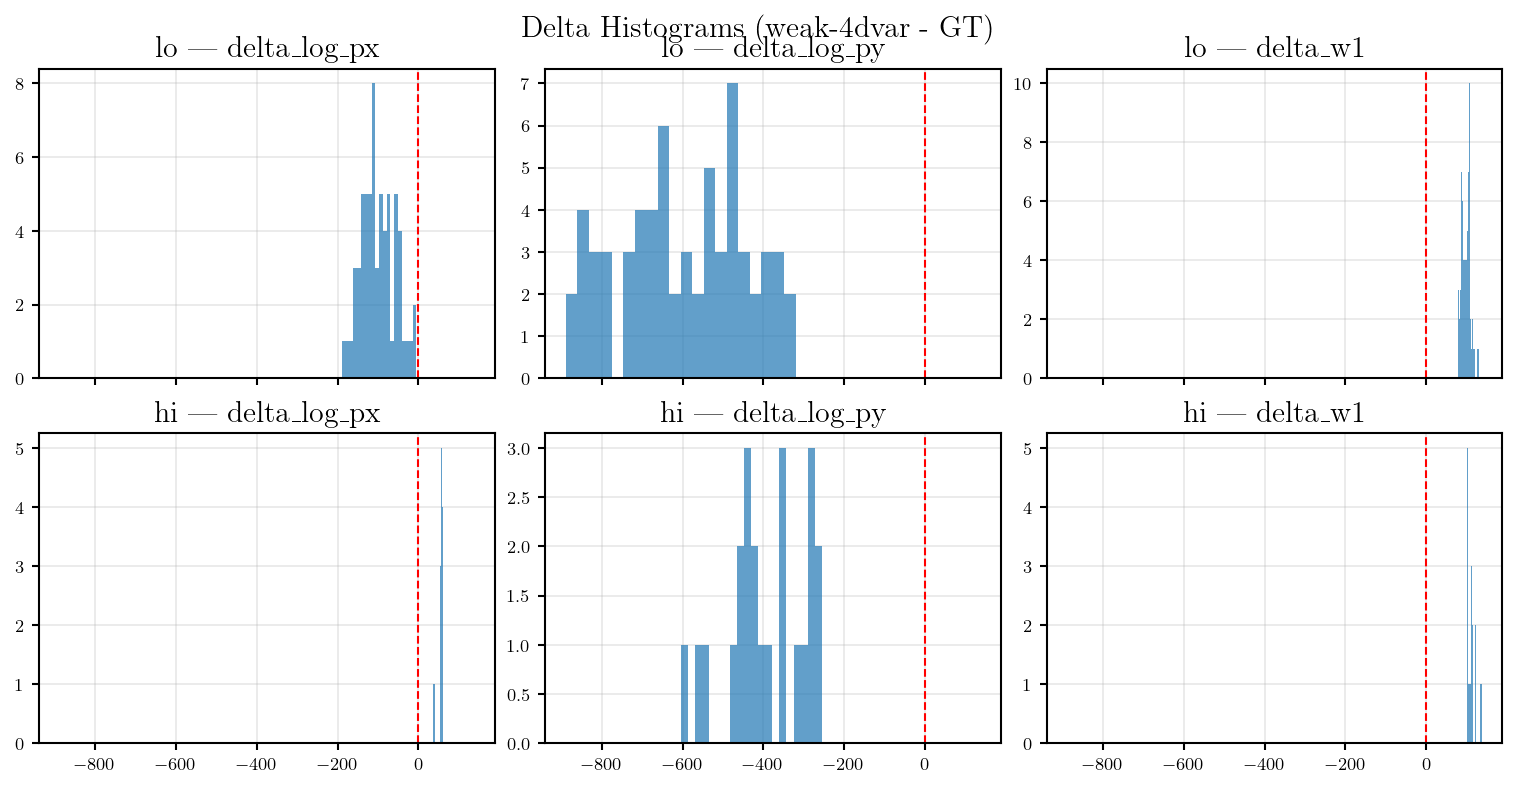

,freq,metric,nan_rate
0,lo,log_px,0.0
1,lo,log_py,0.0
2,lo,w1,0.0
3,hi,log_px,0.0
4,hi,log_py,0.0
5,hi,w1,0.0


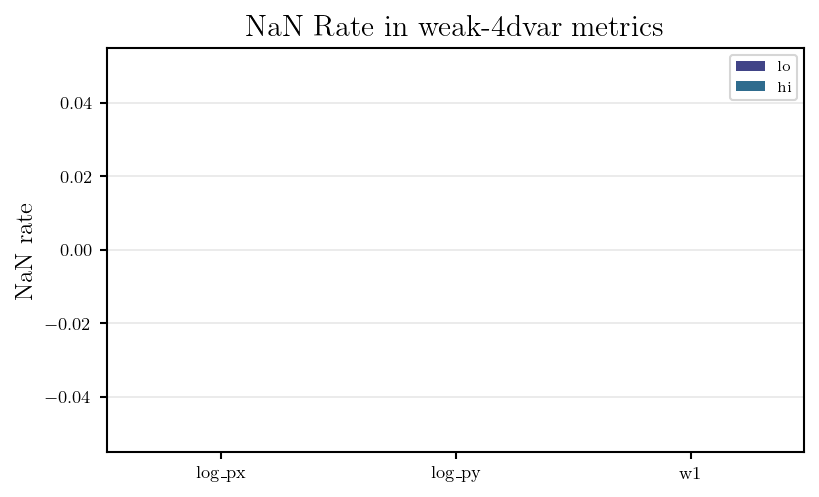

In [16]:
# 1) Distribution comparison: GT vs weak-4dvar for each metric and frequency
metrics = ["log_px", "log_py", "w1"]
fig, axs = plt.subplots(2, 3, figsize=(10, 5), constrained_layout=True)

for r, freq in enumerate(["lo", "hi"]):
    df_f = df_all[df_all["freq"] == freq]
    for c, metric in enumerate(metrics):
        ax = axs[r, c]
        data_gt = df_f.loc[df_f["method"] == "ground-truth", metric].dropna()
        data_w4d = df_f.loc[df_f["method"] == "weak-4dvar", metric].dropna()

        bp = ax.boxplot(
            [data_gt, data_w4d],
            labels=["GT", "weak-4dvar"],
            widths=0.6,
            patch_artist=True,
        )
        bp["boxes"][0].set_facecolor("#d62728")
        bp["boxes"][1].set_facecolor("#1f77b4")
        bp["boxes"][0].set_alpha(0.35)
        bp["boxes"][1].set_alpha(0.35)

        ax.set_title(f"{freq} | {metric}")
        ax.grid(alpha=0.3)

fig.suptitle("Distributions of Metrics by Method", y=1.02)
plt.show()

# 2) Per-sample deltas (weak-4dvar - GT) to spot bias and outliers
fig, axs = plt.subplots(2, 3, figsize=(10, 5), sharex=True, constrained_layout=True)

for r, freq in enumerate(["lo", "hi"]):
    p = pair[pair["freq"] == freq]
    for c, metric in enumerate(metrics):
        ax = axs[r, c]
        dcol = f"delta_{metric}"
        vals = p[dcol].replace([np.inf, -np.inf], np.nan).dropna()
        ax.hist(vals, bins=20, alpha=0.7, color="#1f77b4")
        ax.axvline(0.0, color="red", linestyle="--", linewidth=1)
        ax.set_title(f"{freq} | {dcol}")
        ax.grid(alpha=0.3)

fig.suptitle("Delta Histograms (weak-4dvar - GT)", y=1.02)
plt.show()

# 3) NaN diagnostic by metric/frequency for weak-4dvar
nan_rows = []
for freq in ["lo", "hi"]:
    wf = w4d[w4d["freq"] == freq]
    for metric in metrics:
        rate = wf[metric].isna().mean()
        nan_rows.append({"freq": freq, "metric": metric, "nan_rate": rate})

nan_df = pd.DataFrame(nan_rows)
display(nan_df)

fig, ax = plt.subplots(figsize=(6, 3.5))
for i, freq in enumerate(["lo", "hi"]):
    sub = nan_df[nan_df["freq"] == freq]
    x = np.arange(len(metrics)) + (i - 0.5) * 0.35
    ax.bar(x, sub["nan_rate"], width=0.35, label=freq)

ax.set_xticks(np.arange(len(metrics)))
ax.set_xticklabels(metrics)
ax.set_ylabel("NaN rate")
ax.set_title("NaN Rate in weak-4dvar metrics")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.show()